In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [2]:
# 1. Create Synthetic Data: A steady trend with a "GAP" (Missing Data)
np.random.seed(42)
n = 50
time = np.arange(n)
true_trend = 50 + 0.5 * time  # Gradually increasing temperature
noise = np.random.normal(0, 1, n)
data = true_trend + noise

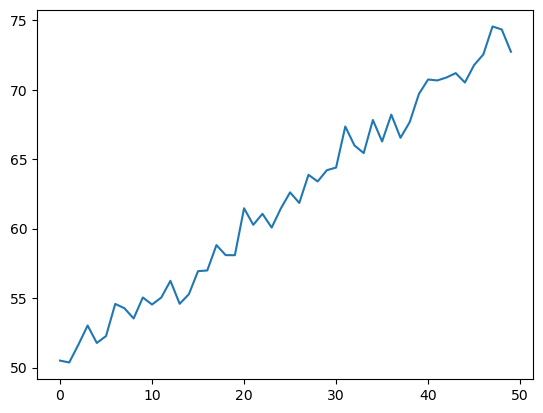

In [12]:
plt.plot(data);

In [13]:
len(data)

50

In [14]:
# Simulate a sensor failure (Days 20 to 30 are missing)
data_with_gap = data.copy()
data_with_gap[20:30] = np.nan 

In [16]:
data_with_gap

array([50.49671415, 50.3617357 , 51.64768854, 53.02302986, 51.76584663,
       52.26586304, 54.57921282, 54.26743473, 53.53052561, 55.04256004,
       54.53658231, 55.03427025, 56.24196227, 54.58671976, 55.27508217,
       56.93771247, 56.98716888, 58.81424733, 58.09197592, 58.0876963 ,
               nan,         nan,         nan,         nan,         nan,
               nan,         nan,         nan,         nan,         nan,
       64.39829339, 67.35227818, 65.98650278, 65.44228907, 67.82254491,
       66.27915635, 68.2088636 , 66.54032988, 67.67181395, 69.69686124,
       70.73846658, 70.67136828, 70.88435172, 71.1988963 , 70.52147801,
       71.78015579, 72.53936123, 74.55712223, 74.34361829, 72.73695984])

In [17]:
# 2. Fit a State-Space Model (Unobserved Components Model)
# This model assumes: Observation = Trend + Noise
ts_model = sm.tsa.UnobservedComponents(data_with_gap, 'local level')
res = ts_model.fit(disp=False)

In [18]:
# 3. Get the "Filtered State" (The model's best guess of the truth)
predict = res.get_prediction(start=0, end=n-1)
predict_mean = predict.predicted_mean
predict_ci = predict.conf_int()

In [22]:
import pandas as pd
predict_ci = pd.DataFrame(predict_ci)

In [34]:
predict_ci.loc[0] = predict_ci.loc[1]
predict_ci.head()

,0,1
0,47.857683,53.135716
1,47.857683,53.135716
2,47.777497,52.988771
3,48.837257,54.046798
4,50.160985,55.370480


In [38]:
predict_mean[0]= np.nan

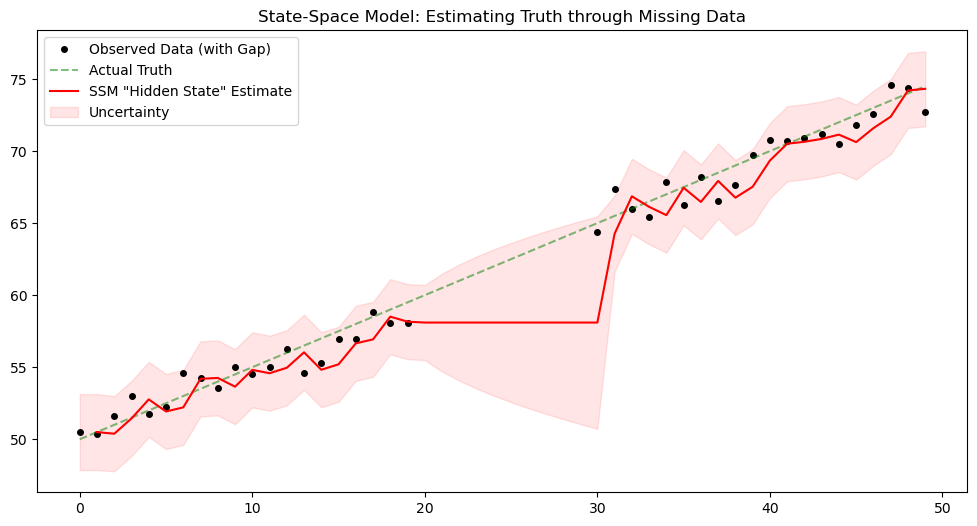

In [39]:
# 4. Visualization
plt.figure(figsize=(12, 6))
plt.plot(time, data_with_gap, 'ko', markersize=4, label='Observed Data (with Gap)')
plt.plot(time, true_trend, 'g--', alpha=0.5, label='Actual Truth')
plt.plot(time, predict_mean, 'r-', label='SSM "Hidden State" Estimate')
plt.fill_between(time, predict_ci.iloc[:, 0], predict_ci.iloc[:, 1], color='r', alpha=0.1, label='Uncertainty')
plt.title("State-Space Model: Estimating Truth through Missing Data")
plt.legend()
plt.show()

Bridge the Gap: Most algorithms (like Simple Moving Average) would return an error or a flat line at zero during the gap. The SSM continues to track the Hidden State. It says, "I can't see the data, but based on the physics of the system I learned before the gap, the trend is likely still here."

Uncertainty Awareness: If you look at the conf_int (the shaded area), you'll notice it gets wider during the gap. The model is "honest"—it admits it is becoming less certain the longer it goes without a new observation.


Noise Filtering: Even when the data is messy, the "State" (the red line) is much smoother than the "Observations" (the black dots). It successfully separates the Signal from the Noise.